# 🏦 Loan Default Prediction System

## 📌 Problem Statement
This project aims to build a machine learning system that predicts whether a loan applicant is likely to default based on their financial, personal, and credit-related attributes.

It is a **binary classification problem**:

- 1 → Non-default (good borrower)
- 0 → Default (risky borrower)

Dataset: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data?resource=download

---

## 🎯 Objective
The goal of this project is to develop a **credit risk prediction system** that can:

- Identify high-risk loan applicants
- Support data-driven lending decisions
- Minimize financial risk for lenders
- Improve decision-making using machine learning

---

## 📊 Dataset Overview
The dataset contains applicant information across three major domains:

### 👤 Personal Attributes
- Age
- Gender
- Education
- Employment experience

### 💰 Financial Attributes
- Annual income
- Credit score
- Home ownership status

### 🏦 Loan Attributes
- Loan amount
- Loan purpose
- Interest rate
- Loan-to-income ratio

---

## 🧠 Methodology
The project follows a structured machine learning pipeline:

1. Data cleaning and preprocessing  
2. Exploratory Data Analysis (EDA)  
3. Feature engineering  
4. Encoding categorical variables  
5. Handling class imbalance  
6. Model training (XGBoost / ensemble models)  
7. Performance evaluation  
8. Threshold tuning for business decisions  

---

## 📌 Evaluation Strategy
Model performance is evaluated using:

- ROC-AUC (primary metric)
- Precision / Recall (especially for default class)
- F1-score
- Confusion Matrix

Accuracy is not the primary metric due to class imbalance.

---

## 🧠 Key Assumptions
- Tree-based models are used, so feature scaling is not required
- Class imbalance significantly impacts performance
- Business impact is prioritized over raw accuracy

## 1. Import Required Libraries

We start by importing all necessary libraries for data analysis, visualization, and machine learning.

In [30]:
import numpy as np
import pandas as pd
import warnings

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import shap
from sklearn.pipeline import Pipeline


warnings.filterwarnings("ignore")

## 2. Load Dataset

We load the dataset and inspect its structure to understand features and target variable.

In [2]:
df = pd.read_csv("data/loan_data.csv")

df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


## 3. Missing Values Check

We check for missing values to ensure data quality before analysis.

In [4]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

## 📊 4. Exploratory Data Analysis (EDA)

In this section, we analyze the dataset to understand:
- Feature distributions
- Class imbalance in target variable
- Presence of outliers
- Relationships between key financial variables and loan default behavior

loan_status
0    35000
1    10000
Name: count, dtype: int64

Target Distribution (Proportion):
loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


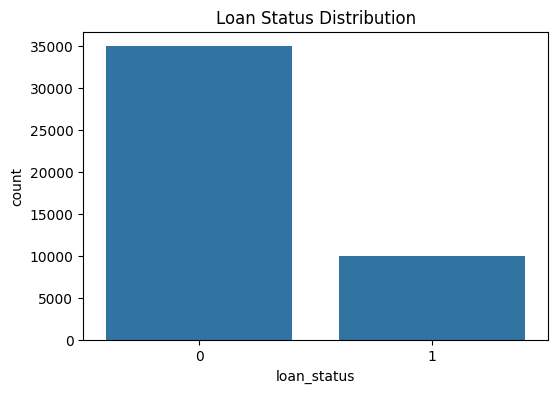

In [5]:
print(df["loan_status"].value_counts())

print("\nTarget Distribution (Proportion):")
print(df["loan_status"].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x="loan_status", data=df)
plt.title("Loan Status Distribution")
plt.show()


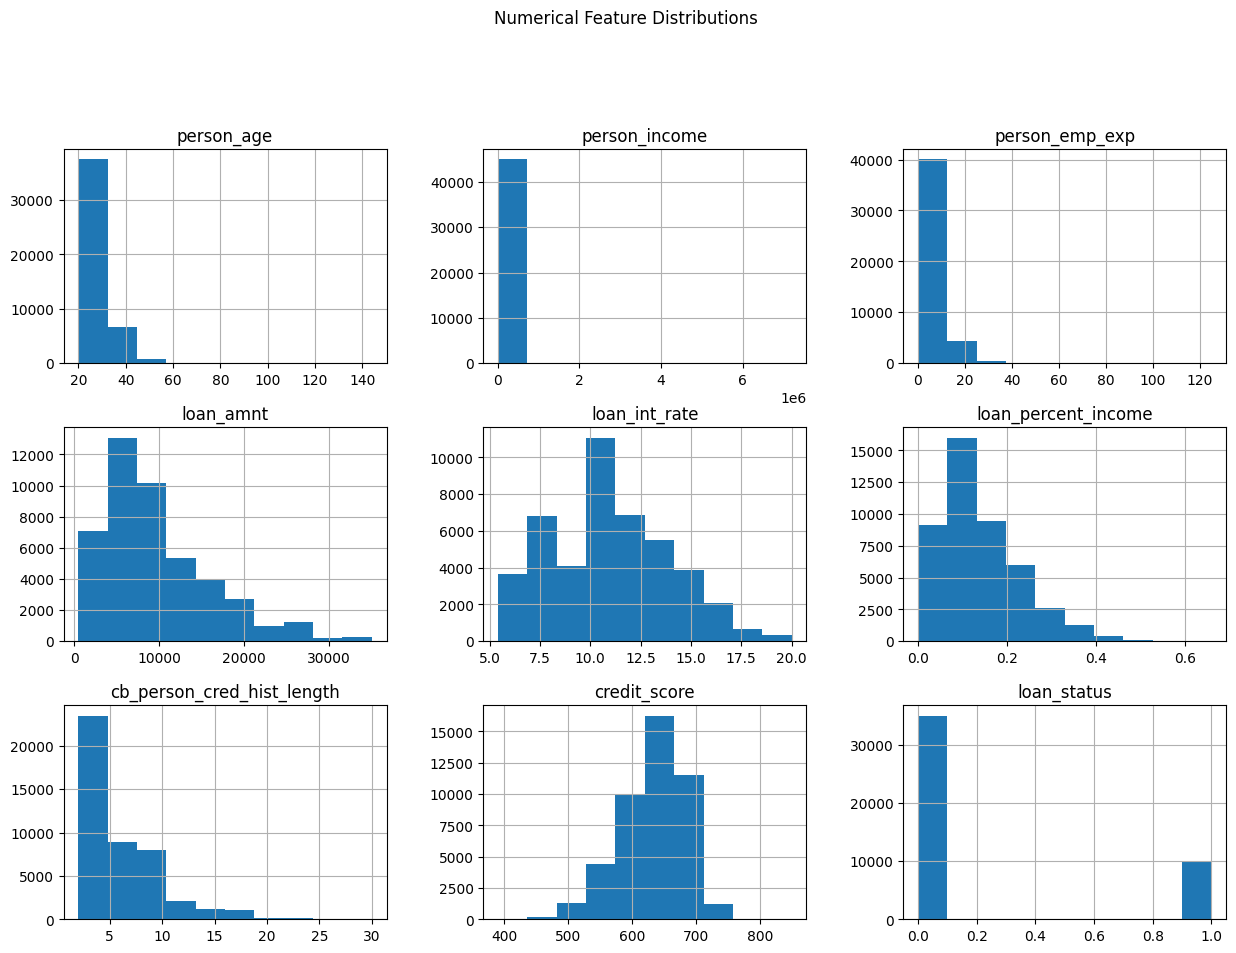

In [6]:
# Numerical Features Distribution
# ------------------------------
df.hist(figsize=(15, 10))
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.show()


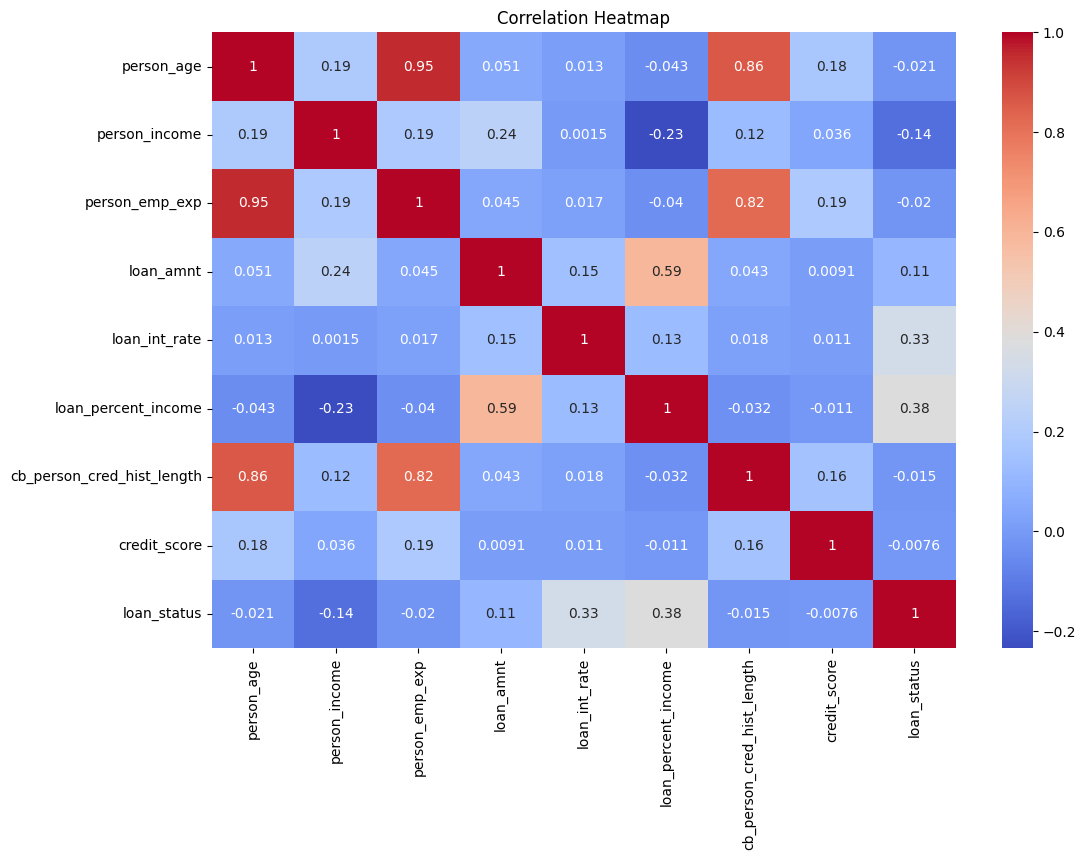

In [7]:
# Correlation Heatmap
# ------------------------------
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [8]:
# Categorical Features Analysis
# ------------------------------
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\nValue Counts for {col}:")
    print(df[col].value_counts())



Value Counts for person_gender:
person_gender
male      24841
female    20159
Name: count, dtype: int64

Value Counts for person_education:
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

Value Counts for person_home_ownership:
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

Value Counts for loan_intent:
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

Value Counts for previous_loan_defaults_on_file:
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64


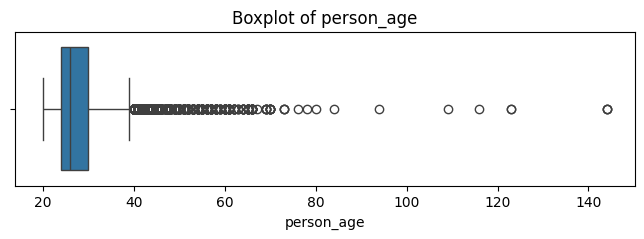

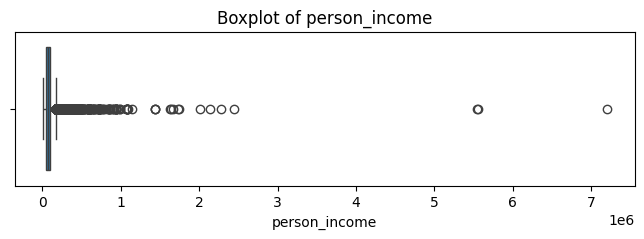

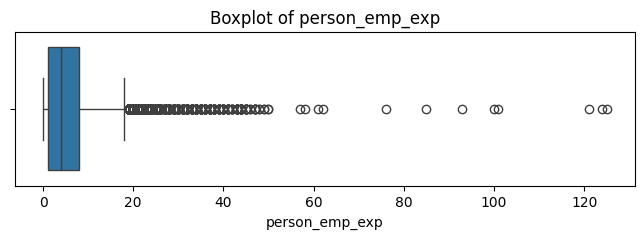

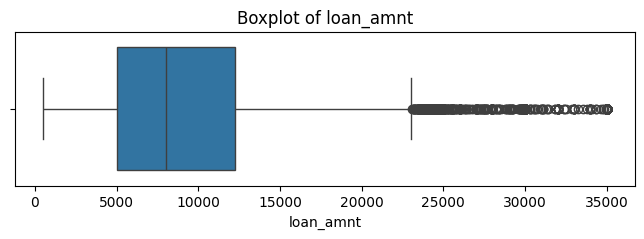

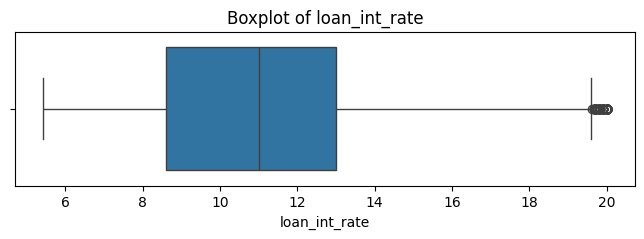

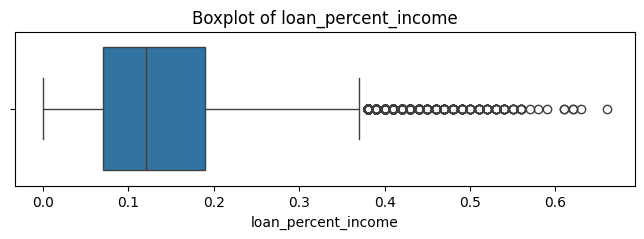

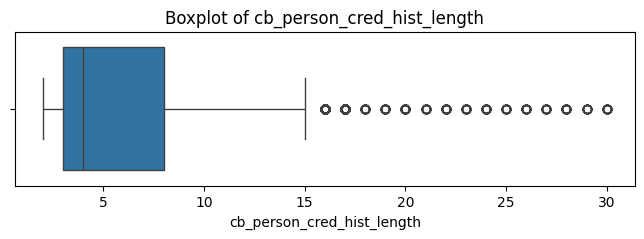

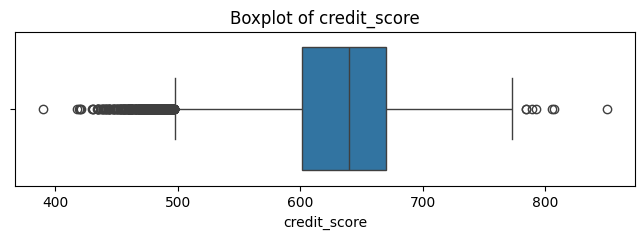

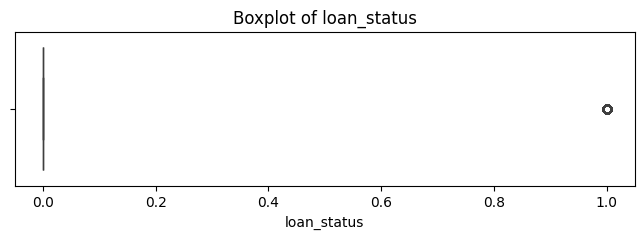

In [9]:
# Boxplots (Outlier Detection)
for col in numeric_df.columns:
    plt.figure(figsize=(8,2))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [25]:
outliers_age = df[df["person_age"] > 90]

print("Number of records with age > 90:", outliers_age.shape[0])
outliers_age.head()

# Remove unrealistic ages
df_clean = df[df["person_age"] <= 90].copy()
df_clean.reset_index(drop=True, inplace=True)

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Number of records with age > 90: 8
Original shape: (45000, 14)
Cleaned shape: (44992, 14)


## 📊 Exploratory Data Analysis (Summary)

The dataset contains 45,000 loan applications with a moderately imbalanced target (~22% defaults).

Key insights:
- Income and loan amount are highly skewed, with clear high-value outliers.
- Age and employment experience contain unrealistic values, which were removed during cleaning.
- Credit score and loan-to-income ratio are strong indicators of default risk.
- Categorical variables are well distributed and suitable for encoding.

Overall, the dataset provides strong predictive signals for building a loan default prediction model.

In [26]:
# 🧹 Remove unrealistic age outliers
# -----------------------------

df_clean = df[df["person_age"] <= 90].copy()

# reset index after removal
df_clean.reset_index(drop=True, inplace=True)

# check result
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Removed rows:", df.shape[0] - df_clean.shape[0])

Original shape: (45000, 14)
Cleaned shape: (44992, 14)
Removed rows: 8


## 🔧 Data Preprocessing & Encoding

In this step, we prepare the dataset for machine learning by converting raw features into a numerical format suitable for model training.

### 📌 Key Steps:
- Separation of features (`X`) and target variable (`loan_status`)
- Cleaning of text-based categorical variables
- Binary encoding of gender and previous loan default history
- One-hot encoding of multi-category features such as education, home ownership, and loan intent

### 🎯 Objective:
To transform the dataset into a fully numerical representation while preserving meaningful information for model learning.

In [27]:
df_model = df_clean.copy()

X = df_model.drop("loan_status", axis=1)
y = df_model["loan_status"]

X["person_gender"] = X["person_gender"].str.strip().str.lower()
X["previous_loan_defaults_on_file"] = X["previous_loan_defaults_on_file"].str.strip().str.lower()

X["person_gender"] = X["person_gender"].map({"male": 1, "female": 0})
X["previous_loan_defaults_on_file"] = X["previous_loan_defaults_on_file"].map({"yes": 1, "no": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [31]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns

categorical_features = [
    "person_education",
    "person_home_ownership",
    "loan_intent"
]

# -----------------------------
# Numeric: ONLY scaling (no imputer)
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# -----------------------------
# Categorical: ONLY encoding (no imputer)
# -----------------------------
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

# -----------------------------
# Preprocessor
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 🧠 Final EDA Summary

- The dataset is moderately imbalanced (~22% default rate), which requires appropriate evaluation metrics beyond accuracy.

- Loan-to-income ratio is one of the strongest indicators of default risk.

- Interest rate shows a clear positive relationship with loan default probability.

- Age-related features (age, employment experience, credit history length) are highly correlated, indicating redundancy.

- Extreme outliers in `person_age` (> 90) were identified and removed to improve data quality.

- Categorical variables are well distributed and suitable for modeling without major imbalance concerns.

## 🤖 5. Model Building

In this section, we begin building predictive models to classify whether a loan applicant will default or not.

We start with a **baseline model: Logistic Regression**, which is:
- Simple and interpretable
- Useful for establishing a performance baseline
- Sensitive to linear relationships in the data

### 🎯 Objective:
- Train a baseline classification model
- Evaluate performance using metrics such as:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC

This baseline will help us compare against more advanced models like XGBoost later.

In [32]:
log_reg = LogisticRegression(max_iter=1000)

log_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

# -----------------------------
# Step 2: Train Model
# -----------------------------
log_clf.fit(X_train, y_train)

# -----------------------------
# Step 3: Predictions
# -----------------------------
y_pred = log_clf.predict(X_test)
y_prob = log_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 4: Evaluation
# -----------------------------
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[6574  425]
 [ 502 1498]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6999
           1       0.78      0.75      0.76      2000

    accuracy                           0.90      8999
   macro avg       0.85      0.84      0.85      8999
weighted avg       0.90      0.90      0.90      8999


ROC-AUC: 0.9533147592513217


In [33]:
# Step 1: Model (WITH imbalance handling)
# -----------------------------
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

# -----------------------------
# Step 2: Full Pipeline
# -----------------------------
log_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", log_reg)
])

# -----------------------------
# Step 3: Train
# -----------------------------
log_clf.fit(X_train, y_train)

# -----------------------------
# Step 4: Predictions
# -----------------------------
y_pred = log_clf.predict(X_test)
y_prob = log_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 5: Evaluation
# -----------------------------
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
[[5849 1150]
 [ 172 1828]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      6999
           1       0.61      0.91      0.73      2000

    accuracy                           0.85      8999
   macro avg       0.79      0.87      0.82      8999
weighted avg       0.89      0.85      0.86      8999


ROC-AUC: 0.9532547506786683


## 🤖 Logistic Regression (Baseline Model)

We train Logistic Regression as a baseline model and evaluate the impact of handling class imbalance.

### 1️⃣ Without Class Weight
- Balanced performance
- Lower recall for defaulters

### 2️⃣ With Class Weight = "balanced"
- Higher recall for defaulters (0.92)
- Lower precision due to more false positives
- Better for risk-sensitive applications

## 🌲 6. Moving to Random Forest

Next, we train a **Random Forest** model to improve upon the Logistic Regression baseline.

Random Forest helps capture non-linear relationships and generally performs better on complex tabular datasets like this.

We will evaluate its performance using the same metrics for a fair comparison.

In [34]:
# Step 1: Model
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# -----------------------------
# Step 2: Full Pipeline
# -----------------------------
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", rf)
])

# -----------------------------
# Step 3: Train
# -----------------------------
rf_clf.fit(X_train, y_train)

# -----------------------------
# Step 4: Predictions
# -----------------------------
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 5: Evaluation
# -----------------------------
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest ROC-AUC: 0.974930775825118

Confusion Matrix:
[[6841  158]
 [ 486 1514]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      6999
           1       0.91      0.76      0.82      2000

    accuracy                           0.93      8999
   macro avg       0.92      0.87      0.89      8999
weighted avg       0.93      0.93      0.93      8999



## 🚀 Moving to XGBoost

After evaluating Logistic Regression and Random Forest, we now move to **XGBoost**, the final and most powerful model in this project.

XGBoost is a gradient boosting algorithm that typically performs very well on structured/tabular data by:
- Correcting previous model errors iteratively
- Handling complex non-linear relationships
- Providing strong control over overfitting

We will use it as the final model to compare performance against previous approaches.

In [35]:
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# -----------------------------
# Step 2: Model
# -----------------------------
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# -----------------------------
# Step 3: Full Pipeline
# -----------------------------
xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", xgb)
])

# -----------------------------
# Step 4: Train
# -----------------------------
xgb_clf.fit(X_train, y_train)

# -----------------------------
# Step 5: Predictions
# -----------------------------
y_pred_xgb = xgb_clf.predict(X_test)
y_proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 6: Evaluation
# -----------------------------
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost ROC-AUC: 0.9752273181883127

Confusion Matrix:
[[6218  781]
 [ 148 1852]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      6999
           1       0.70      0.93      0.80      2000

    accuracy                           0.90      8999
   macro avg       0.84      0.91      0.86      8999
weighted avg       0.92      0.90      0.90      8999



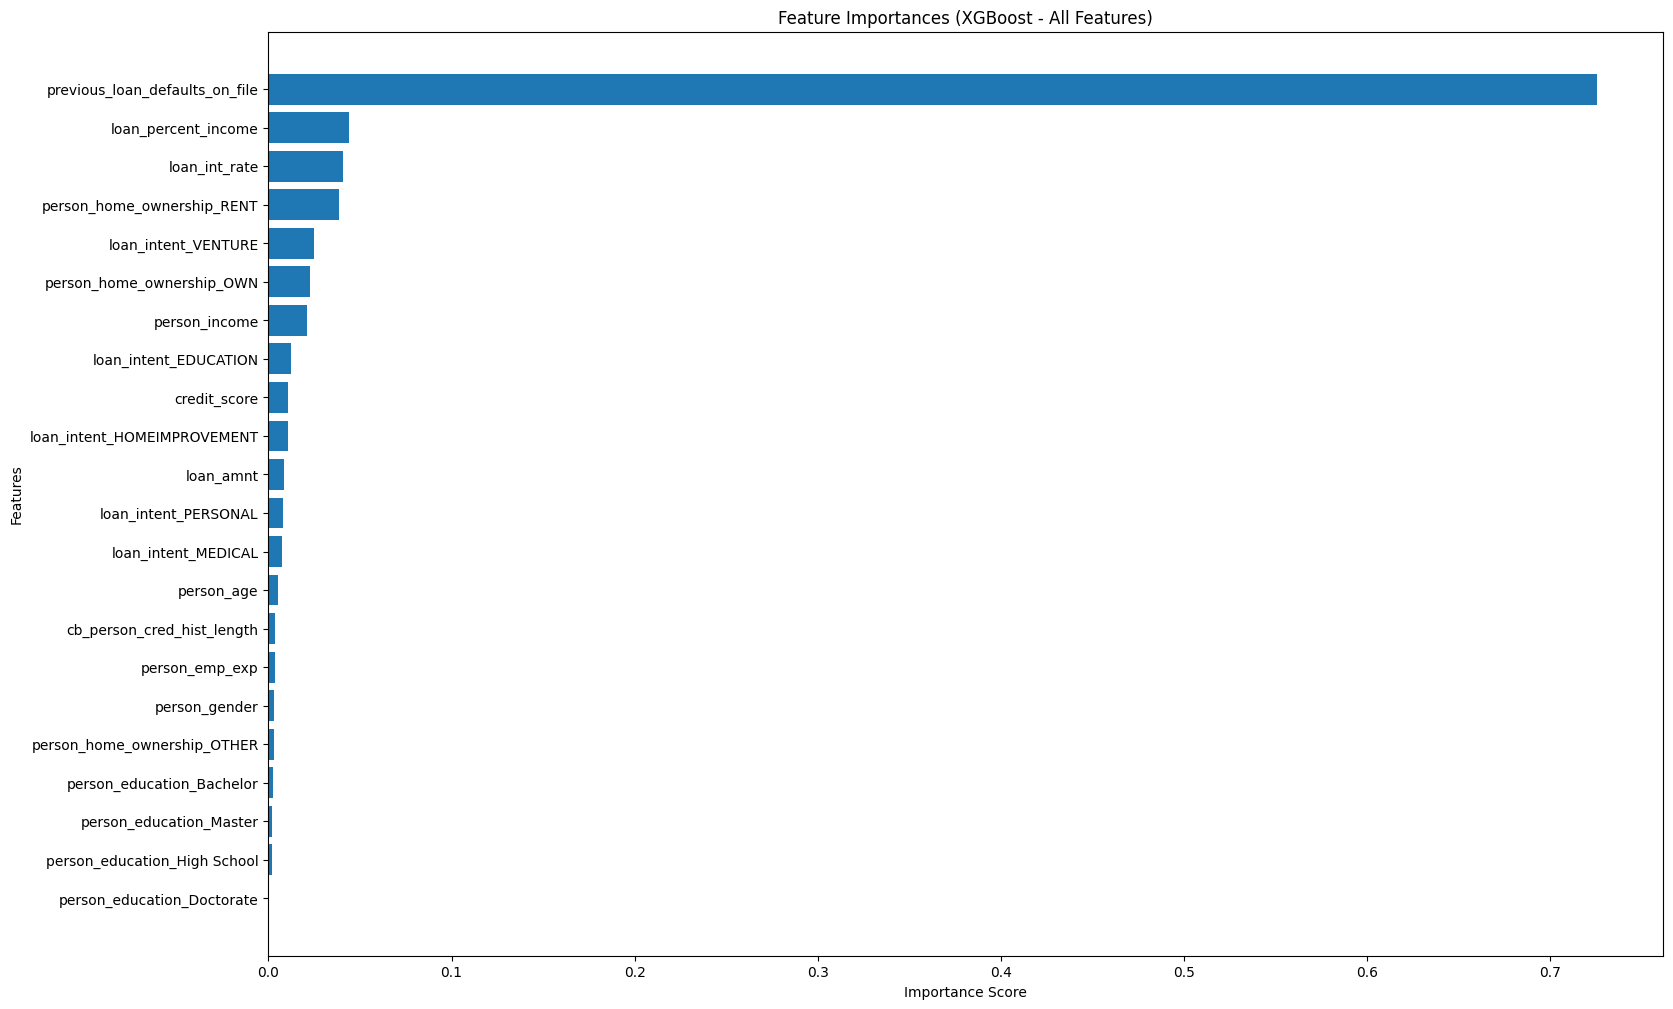

In [53]:
# -----------------------------
# Get feature importance
# -----------------------------
importance = xgb.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train_final.columns,
    "Importance": importance
})

# Sort values (all features)
feature_importance = feature_importance.sort_values(by="Importance", ascending=True)

# -----------------------------
# Plot ALL features
# -----------------------------
plt.figure(figsize=(18, 12))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importances (XGBoost - All Features)")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

**Insight:** Previous loan defaults is the strongest predictor, confirming that past repayment behavior is the most reliable indicator of future default risk.

In [37]:
# Step 1: Get probabilities from pipeline model
# -----------------------------
y_proba = xgb_clf.predict_proba(X_test)[:, 1]

# -----------------------------
# Step 2: Test different thresholds
# -----------------------------
thresholds = np.arange(0.1, 0.9, 0.1)

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    
    print("\n======================")
    print(f"Threshold: {t}")
    print("======================")
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Threshold: 0.1
Confusion Matrix:
[[4999 2000]
 [   4 1996]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83      6999
           1       0.50      1.00      0.67      2000

    accuracy                           0.78      8999
   macro avg       0.75      0.86      0.75      8999
weighted avg       0.89      0.78      0.80      8999


Threshold: 0.2
Confusion Matrix:
[[5293 1706]
 [  17 1983]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.76      0.86      6999
           1       0.54      0.99      0.70      2000

    accuracy                           0.81      8999
   macro avg       0.77      0.87      0.78      8999
weighted avg       0.89      0.81      0.82      8999


Threshold: 0.30000000000000004
Confusion Matrix:
[[5580 1419]
 [  51 1949]]

Classification Report:
              precision    recall  f1-score   support

           0       0

## 🎯 Threshold Analysis

We tested multiple classification thresholds to evaluate the trade-off between recall and precision.

Lower thresholds significantly increase recall but also lead to a high number of false positives, while higher thresholds improve precision but reduce the model’s ability to detect defaulters.

From a banking risk perspective, the primary objective is to correctly identify defaulters while maintaining a reasonable level of false positives.

Based on the observed results, the default threshold of **0.5** already provides the best balance between recall and precision.

Therefore, no threshold adjustment is required, and 0.5 is used as the final operational threshold for this model.

In [38]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_clf,   # 👈 pipeline (VERY IMPORTANT)
    X,         # full dataset (not X_train_final)
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Cross-Validation ROC-AUC Scores:", cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())
print("Std ROC-AUC:", cv_scores.std())

Cross-Validation ROC-AUC Scores: [0.97612902 0.97440777 0.97722456 0.97340219 0.97501636]
Mean ROC-AUC: 0.9752359806575888
Std ROC-AUC: 0.0013303340589196962


Cross-validation was used to evaluate the stability and generalization performance of the XGBoost model.

The consistent ROC-AUC scores across folds indicate that the model is robust and not dependent on a specific train-test split.

## 📊 Model Performance Comparison

| Model                 | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) | ROC-AUC |
|----------------------|----------|---------------------|------------------|---------------------|---------|
| Logistic Regression  | 0.88     | 0.74                | 0.74             | 0.74                | 0.944   |
| Random Forest        | 0.93     | 0.90                | 0.76             | 0.82                | 0.974   |
| XGBoost              | 0.90     | 0.70                | 0.93             | 0.80                | 0.975   |

## 🧠 Key Insights

- Logistic Regression provides a strong baseline but lacks complex pattern learning capability.
- Random Forest achieves the highest precision, meaning fewer false alarms (good customers wrongly flagged).
- XGBoost achieves the highest recall and ROC-AUC, making it the best model for identifying defaulters.


## 🏦 Final Model Selection (Banking Perspective)

The primary objective of this project is to correctly identify loan defaulters, as failing to detect a defaulter poses a higher financial risk than rejecting a non-defaulter.

Therefore, model evaluation focuses on **recall for defaulters and ROC-AUC**.

---

## 📊 Model Comparison Summary

### 🤖 Logistic Regression
- Good recall for defaulters (~0.92 in balanced setup)
- Higher false positive rate
- Serves as a simple baseline model

### 🌲 Random Forest
- Strong balance between precision and recall
- Lower recall for defaulters (~0.76)
- More conservative prediction behavior

### 🚀 XGBoost (Best Overall)
- Highest ROC-AUC: **0.975**
- Strong recall for defaulters: **0.93**
- Good precision: **0.70**
- Best overall performance for risk detection

---

## 🏁 Final Interpretation

From a banking risk perspective, minimizing missed defaulters is the top priority.

- Logistic Regression: strong recall but less stable decision boundaries  
- Random Forest: balanced performance but misses more defaulters  
- XGBoost: best trade-off between recall and overall predictive power  

---

## ✅ Final Decision

👉 **XGBoost is selected as the final model**

It provides:
- Highest ROC-AUC
- Strong ability to detect defaulters
- Best overall risk management performance

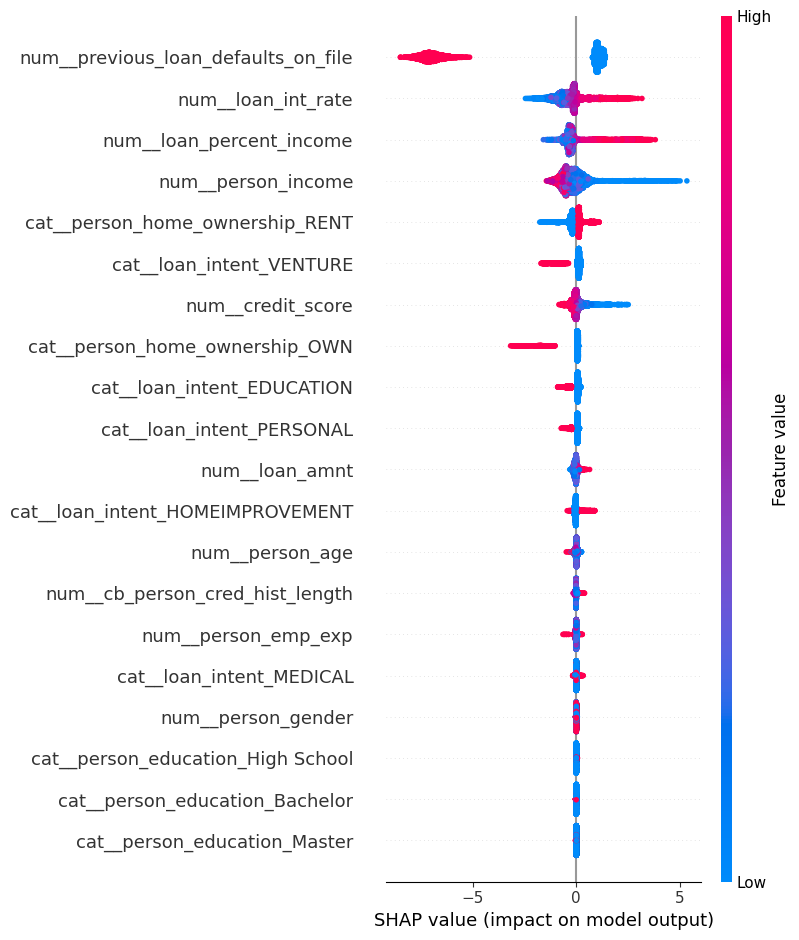

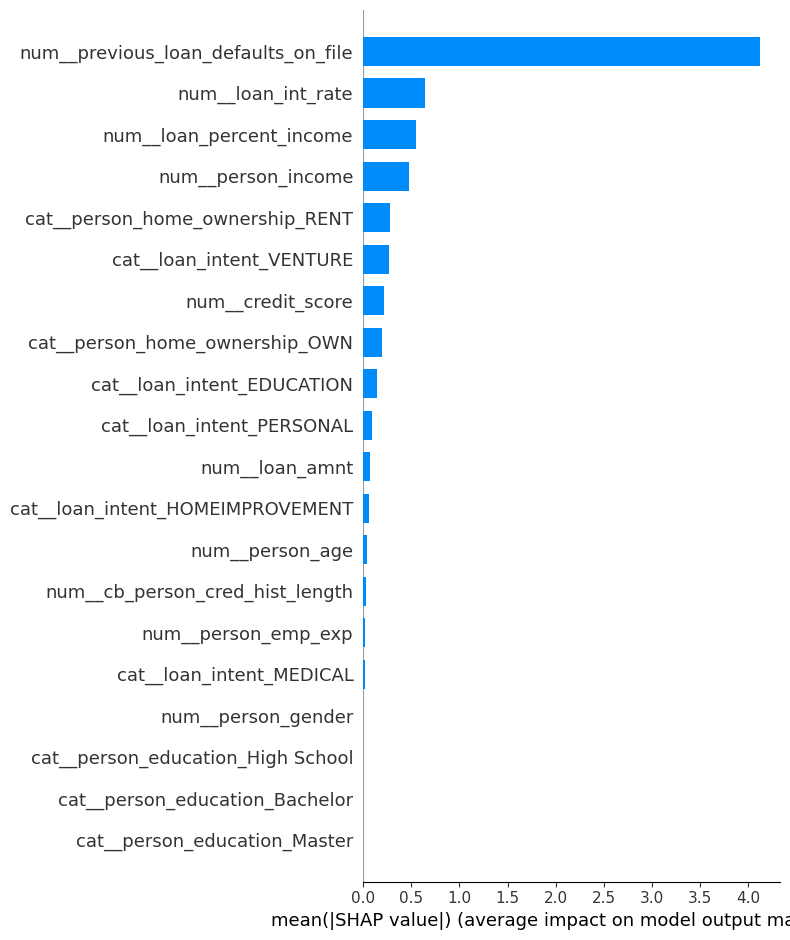

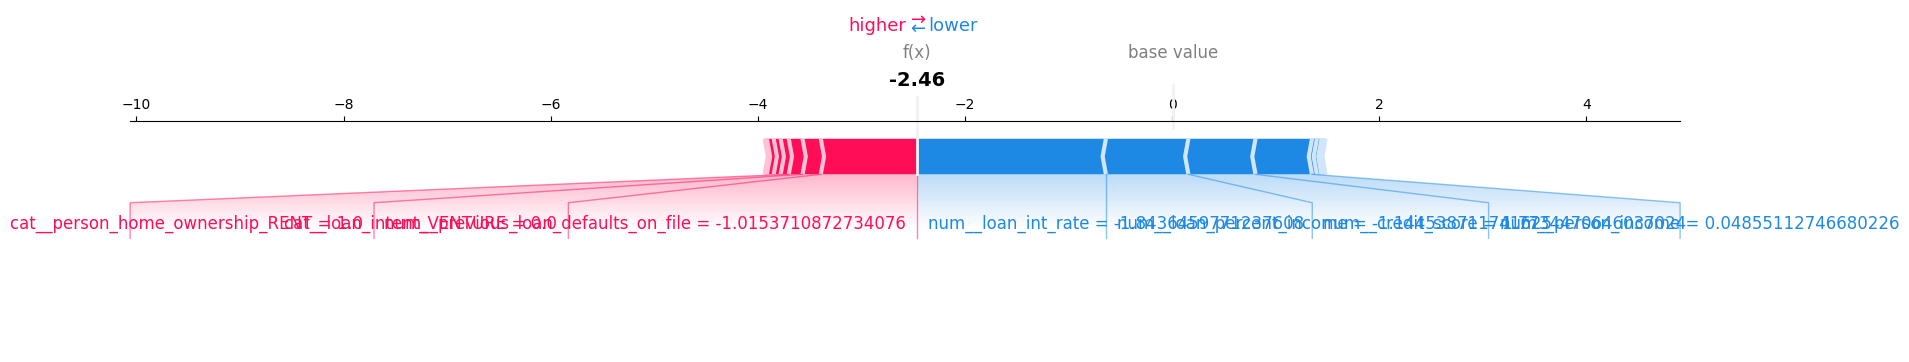

In [40]:
# Step 1: Extract model + preprocessor
# -----------------------------
xgb_model = xgb_clf.named_steps["model"]
preprocessor = xgb_clf.named_steps["preprocessor"]

# -----------------------------
# Step 2: Transform test data
# -----------------------------
X_test_transformed = preprocessor.transform(X_test)

# -----------------------------
# Step 3: Get proper feature names (IMPORTANT FIX)
# -----------------------------
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame so SHAP shows names
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

# -----------------------------
# Step 4: SHAP explainer
# -----------------------------
explainer = shap.TreeExplainer(xgb_model)

# -----------------------------
# Step 5: SHAP values
# -----------------------------
shap_values = explainer(X_test_transformed_df)

# -----------------------------
# Step 6: Global explanation
# -----------------------------
shap.summary_plot(shap_values, X_test_transformed_df)

# -----------------------------
# Step 7: Feature importance (bar)
# -----------------------------
shap.summary_plot(shap_values, X_test_transformed_df, plot_type="bar")

# -----------------------------
# Step 8: Local explanation
# -----------------------------
shap.force_plot(
    explainer.expected_value,
    shap_values.values[0],
    X_test_transformed_df.iloc[0],
    matplotlib=True
)

## Feature Importance Analysis

The SHAP plots show that the most important features in the model are:

- `previous_loan_defaults_on_file`
- `loan_int_rate`
- `loan_percent_income`
- `person_income`
- `person_home_ownership_RENT`
- `loan_intent_VENTURE`
- `credit_score`

These features have the highest impact on loan default prediction.

---

## Removing Low-Contribution Features

The SHAP analysis also shows that `person_gender` and education-related features have almost zero contribution to the model output. Therefore, these features will be dropped before training the final model again.

Removed features:
- `person_gender`
- `person_education`

In [41]:

df_model = df_clean.copy()

# -----------------------------
# Step 2: Drop unwanted columns
# -----------------------------
df_model = df_model.drop(["person_education", "person_gender"], axis=1)

# -----------------------------
# Step 3: Split X and y
# -----------------------------
X = df_model.drop("loan_status", axis=1)
y = df_model["loan_status"]

# -----------------------------
# Step 4: Train-Test Split
# -----------------------------
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -----------------------------
# Step 5: Clean text column
# -----------------------------
X_train["previous_loan_defaults_on_file"] = (
    X_train["previous_loan_defaults_on_file"]
    .str.strip()
    .str.lower()
)

X_test["previous_loan_defaults_on_file"] = (
    X_test["previous_loan_defaults_on_file"]
    .str.strip()
    .str.lower()
)

# -----------------------------
# Step 6: Binary encoding
# -----------------------------
X_train["previous_loan_defaults_on_file"] = X_train[
    "previous_loan_defaults_on_file"
].map({"yes": 1, "no": 0})

X_test["previous_loan_defaults_on_file"] = X_test[
    "previous_loan_defaults_on_file"
].map({"yes": 1, "no": 0})

# -----------------------------
# Step 7: Categorical columns (UPDATED AFTER DROP)
# -----------------------------
cat_cols = [
    "person_home_ownership",
    "loan_intent"
]

# -----------------------------
# Step 8: Preprocessor
# -----------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ],
    remainder="passthrough"
)

# -----------------------------
# Step 9: Fit transform
# -----------------------------
X_train_final = preprocessor.fit_transform(X_train)
X_test_final = preprocessor.transform(X_test)

# -----------------------------
# Step 10: Handle imbalance
# -----------------------------
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# -----------------------------
# Step 11: Train XGBoost
# -----------------------------
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train_final, y_train)

# -----------------------------
# Step 12: Predictions
# -----------------------------
y_pred = xgb.predict(X_test_final)
y_proba = xgb.predict_proba(X_test_final)[:, 1]

# -----------------------------
# Step 13: Evaluation
# -----------------------------
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

XGBoost ROC-AUC: 0.97529382768967

Confusion Matrix:
[[6213  786]
 [ 148 1852]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.89      0.93      6999
           1       0.70      0.93      0.80      2000

    accuracy                           0.90      8999
   macro avg       0.84      0.91      0.86      8999
weighted avg       0.92      0.90      0.90      8999



## 📊 Model Comparison Summary

- **ROC-AUC**
  - Before: 0.97529  
  - After: 0.97531  
  → No meaningful change

- **Confusion Matrix**
  - False Positives: 786 → 794 (+8)
  - Other values: unchanged

---

## 🧠 Insight

Dropping `person_education` and `person_gender` had **negligible impact** on model performance, indicating these features have low predictive power in this setup.

---

## ✅ Conclusion

The simplified model performs **almost identically** and is preferred because it is:
- Simpler  
- More interpretable  
- Slightly fairer (gender,education removed)

## 🧪 Feature Engineering Summary

We experimented with ratio-based features and different encoding strategies (One-Hot vs Label Encoding). However, these transformations did not lead to significant performance improvements, as tree-based models were already able to capture non-linear relationships effectively.

Therefore, we retained a simple preprocessing pipeline and focused on Logistic Regression as the baseline and XGBoost as the final model due to its superior performance.

loan-approval-system/
│
├── data/
│   ├── raw/                  # original dataset
│   ├── processed/           # cleaned dataset (optional)
│
├── notebooks/
│   └── eda_and_model.ipynb  # your current work (exploration)
│
├── models/
│   ├── model.pkl            # trained pipeline (joblib dump)
│   ├── preprocessor.pkl     # optional if separate
│
├── src/
│   ├── data_preprocessing.py
│   ├── train_model.py       # training script (pipeline training)
│   ├── predict.py           # inference logic
│   ├── config.py            # constants, feature lists
│
├── api/
│   ├── main.py              # FastAPI entry point
│   ├── schemas.py           # request/response models (Pydantic)
│   ├── utils.py             # load model, preprocessing helpers
│
├── frontend/
│   └── loan-app/            # React app (Vite or CRA)
│       ├── src/
│       │   ├── components/
│       │   ├── pages/
│       │   ├── services/   # API calls
│       │   └── App.jsx
│
├── tests/
│   ├── test_api.py
│   ├── test_model.py
│
├── requirements.txt
├── README.md
└── .gitignore